# Exploratory Data Analysis — Home Credit Default Risk

This notebook performs an initial exploration of the `application_train.csv` dataset from the Home Credit Default Risk competition.  
The goal is to build intuition about the data before any feature engineering or modelling: understand the target distribution, identify missing values, and spot patterns in the key features.

In [16]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Consistent visual style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13

DATA_PATH = '../data/raw/application_train.csv'

---
## 1. Load the Data

We read `application_train.csv` and do a quick sanity check on shape, column dtypes, and the first few rows.  
This confirms the file loaded correctly and gives us a first look at raw values.

In [17]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

Shape: 307,511 rows x 122 columns


In [18]:
# Column dtypes — useful for deciding which columns are numerical vs categorical
dtype_summary = df.dtypes.value_counts().rename('count').to_frame()
print(dtype_summary)
print()
df.dtypes.head(30)

         count
float64     65
int64       41
object      16



SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE             object
CODE_GENDER                    object
FLAG_OWN_CAR                   object
FLAG_OWN_REALTY                object
CNT_CHILDREN                    int64
AMT_INCOME_TOTAL              float64
AMT_CREDIT                    float64
AMT_ANNUITY                   float64
AMT_GOODS_PRICE               float64
NAME_TYPE_SUITE                object
NAME_INCOME_TYPE               object
NAME_EDUCATION_TYPE            object
NAME_FAMILY_STATUS             object
NAME_HOUSING_TYPE              object
REGION_POPULATION_RELATIVE    float64
DAYS_BIRTH                      int64
DAYS_EMPLOYED                   int64
DAYS_REGISTRATION             float64
DAYS_ID_PUBLISH                 int64
OWN_CAR_AGE                   float64
FLAG_MOBIL                      int64
FLAG_EMP_PHONE                  int64
FLAG_WORK_PHONE                 int64
FLAG_CONT_MOBILE                int64
FLAG_PHONE  

In [19]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


---
## 2. Target Variable — Class Imbalance

`TARGET = 1` means the client **defaulted** (had payment difficulties); `TARGET = 0` means they repaid on time.  
Credit risk datasets are almost always heavily imbalanced — the majority of borrowers repay. Understanding the ratio is critical because it directly affects:
- Which evaluation metric to use (AUC-ROC, precision-recall, F1 rather than accuracy)
- Whether to apply class-weighting, oversampling (SMOTE), or undersampling during training

In [20]:
target_counts = df['TARGET'].value_counts().sort_index()
target_pct    = df['TARGET'].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({'count': target_counts, 'percent (%)': target_pct.round(2)})
summary.index = summary.index.map({0: 'No default (0)', 1: 'Default (1)'})
print(summary)
print(f'\nImbalance ratio  —  majority : minority = {target_counts[0]/target_counts[1]:.1f} : 1')

                 count  percent (%)
TARGET                             
No default (0)  282686        91.93
Default (1)      24825         8.07

Imbalance ratio  —  majority : minority = 11.4 : 1


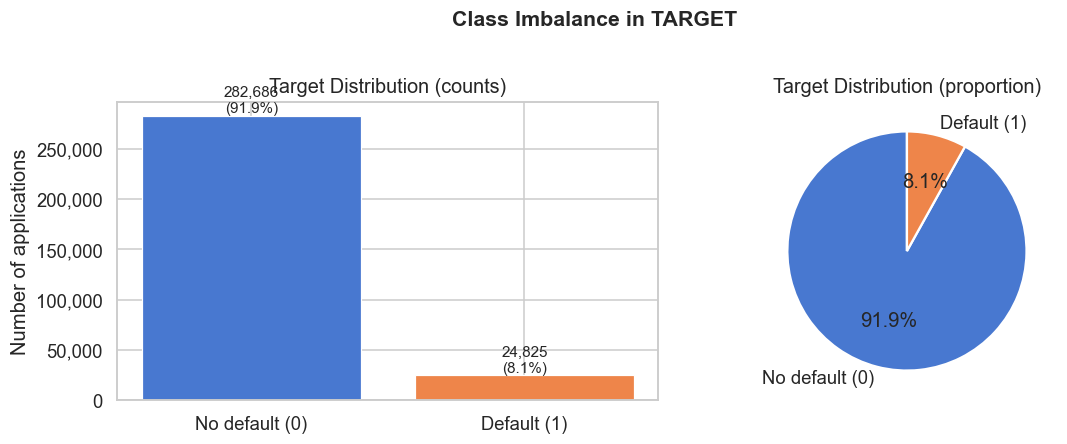

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

colors = sns.color_palette('muted', 2)
axes[0].bar(
    ['No default (0)', 'Default (1)'],
    target_counts.values,
    color=colors, edgecolor='white', linewidth=0.8
)
for i, (v, p) in enumerate(zip(target_counts.values, target_pct.values)):
    axes[0].text(i, v + 500, f'{v:,}\n({p:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Target Distribution (counts)')
axes[0].set_ylabel('Number of applications')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].pie(
    target_counts.values,
    labels=['No default (0)', 'Default (1)'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Target Distribution (proportion)')

plt.suptitle('Class Imbalance in TARGET', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Missing Values

Many real-world datasets have missing values, and the Home Credit dataset is no exception. Before modelling we need to know:
1. **Which columns** have missing data
2. **How much** is missing — a column missing >70-80% of values may not be worth keeping
3. **Whether missingness is informative** (e.g. `OWN_CAR_AGE` is missing for people who do not own a car)

This section counts and visualises missing values so we can make informed imputation or dropping decisions later.

In [22]:
missing = (
    df.isnull().sum()
    .rename('missing_count')
    .to_frame()
    .assign(missing_pct=lambda x: (x['missing_count'] / len(df) * 100).round(2))
    .query('missing_count > 0')
    .sort_values('missing_pct', ascending=False)
)

print(f'Columns with missing values: {len(missing)} / {df.shape[1]}')
print('\nTop 20 by missing %:')
missing.head(20)

Columns with missing values: 67 / 122

Top 20 by missing %:


,missing_count,missing_pct
COMMONAREA_MEDI,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_AVG,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,210199,68.35


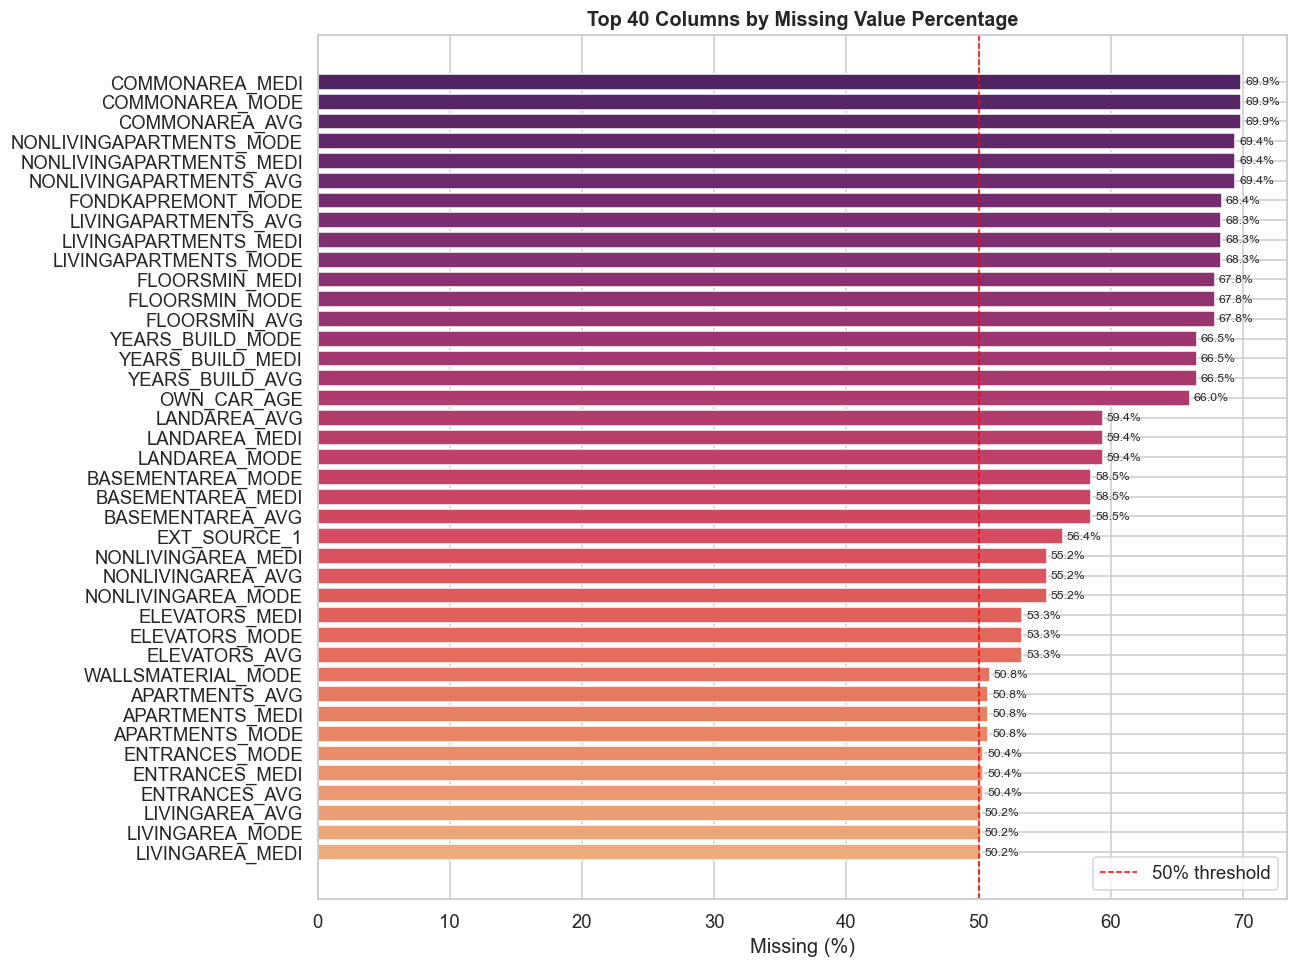

In [23]:
top_missing = missing.head(40)

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(
    top_missing.index[::-1],
    top_missing['missing_pct'][::-1],
    color=sns.color_palette('flare', len(top_missing)),
    edgecolor='white'
)
ax.axvline(50, color='red', linestyle='--', linewidth=1, label='50% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Top 40 Columns by Missing Value Percentage', fontweight='bold')
ax.legend()
for bar, pct in zip(bars, top_missing['missing_pct'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

In [24]:
buckets = {
    '>50% missing':   (missing['missing_pct'] > 50).sum(),
    '20-50% missing': ((missing['missing_pct'] >= 20) & (missing['missing_pct'] <= 50)).sum(),
    '5-20% missing':  ((missing['missing_pct'] >= 5)  & (missing['missing_pct'] < 20)).sum(),
    '<5% missing':    (missing['missing_pct'] < 5).sum(),
}
pd.Series(buckets, name='column_count').to_frame()

,column_count
>50% missing,41
20-50% missing,9
5-20% missing,7
<5% missing,10


### 3a. Drop High-Missing Columns & Impute EXT_SOURCE_1

Before moving on we apply the first round of data cleaning based on what the missing-value analysis revealed:

1. **Drop columns with >50% missing** — columns this sparse offer little signal and mostly introduce noise or require complex imputation strategies that aren't justified at the EDA stage.  
   *Exception:* `EXT_SOURCE_1` is retained because it is one of the strongest predictors of default despite having high missingness (~56%).

2. **Add a missingness indicator for EXT_SOURCE_1** — the fact that a value is *absent* can itself be informative (e.g. credit bureau data unavailable for thin-file applicants). We capture this signal with a binary flag `EXT_SOURCE_1_missing` *before* filling the gaps.

3. **Impute EXT_SOURCE_1 with its median** — median is robust to the skewed distribution of credit scores and prevents data leakage (we use the training-set median only).

In [25]:
print(f'Shape BEFORE cleaning: {df.shape[0]:,} rows  x  {df.shape[1]} columns')

# --- 1. Identify columns with >50% missing, excluding EXT_SOURCE_1 ---
missing_pct_all = df.isnull().mean() * 100
cols_to_drop = [
    col for col in df.columns
    if missing_pct_all[col] > 50 and col != 'EXT_SOURCE_1'
]
print(f'Columns to drop (>50% missing, EXT_SOURCE_1 excluded): {len(cols_to_drop)}')
print(cols_to_drop)

df = df.drop(columns=cols_to_drop)

# --- 2. Binary missingness flag for EXT_SOURCE_1 ---
df['EXT_SOURCE_1_missing'] = df['EXT_SOURCE_1'].isnull().astype(np.int8)
n_flagged = df['EXT_SOURCE_1_missing'].sum()
pct_flagged = df['EXT_SOURCE_1_missing'].mean() * 100
print(f'EXT_SOURCE_1 missing rows flagged: {n_flagged:,} ({pct_flagged:.1f}%)')

# --- 3. Impute EXT_SOURCE_1 with training-set median ---
ext1_median = df['EXT_SOURCE_1'].median()
df['EXT_SOURCE_1'] = df['EXT_SOURCE_1'].fillna(ext1_median)
print(f'EXT_SOURCE_1 imputed with median = {ext1_median:.4f}')
print(f'EXT_SOURCE_1 missing after imputation: {df["EXT_SOURCE_1"].isnull().sum()}')

print(f'Shape AFTER  cleaning: {df.shape[0]:,} rows  x  {df.shape[1]} columns')
print(f'Net change: {len(cols_to_drop)} columns dropped, 1 flag column added')


Shape BEFORE cleaning: 307,511 rows  x  122 columns
Columns to drop (>50% missing, EXT_SOURCE_1 excluded): 40
['OWN_CAR_AGE', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE']
EXT_SOURCE_1 missing rows flagged: 173,378 (56.4%)
EXT_SOURCE_1 imputed with median = 0.5060

### 3b. Impute Remaining Missing Values

After dropping >50%-missing columns and handling `EXT_SOURCE_1`, a number of columns in the **5–50% missing** range still need attention.

Strategy:
- **Missingness flag** (`_missing` binary column) for every column with **>20% missing** — the absence pattern itself can carry predictive signal.
- **Numerical columns** → impute with the **training-set median** (robust to skew and outliers).
- **Categorical columns** → impute with the **mode** (most frequent category; simple and interpretable).

We recompute `missing_pct_all` on the current dataframe so the calculation reflects the columns already dropped in step 3a.

In [26]:
# Recompute on post-drop dataframe
missing_pct_all = df.isnull().mean() * 100
still_missing = missing_pct_all[missing_pct_all > 0].sort_values(ascending=False)
print(f'Columns still missing after step 3a: {len(still_missing)}')
print(still_missing.to_string())

EXCLUDE = {'SK_ID_CURR', 'TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_1_missing'}
num_cols  = [c for c in df.select_dtypes(include='number').columns
             if c not in EXCLUDE and missing_pct_all[c] > 0]
cat_cols  = [c for c in df.select_dtypes(include='object').columns
             if c not in EXCLUDE and missing_pct_all[c] > 0]

print(f'Numerical columns to impute : {len(num_cols)}')
print(f'Categorical columns to impute: {len(cat_cols)}')

# --- Missingness flags for columns >20% missing ---
flag_cols = [c for c in num_cols + cat_cols if missing_pct_all[c] > 20]
for col in flag_cols:
    df[col + '_missing'] = df[col].isnull().astype('int8')
print(f'Missingness flag columns added: {len(flag_cols)} -> {[c+"_missing" for c in flag_cols]}')

# --- Impute numerical with median ---
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# --- Impute categorical with mode ---
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

remaining = df.isnull().sum().sum()
print(f'Total remaining nulls after imputation: {remaining}')
print(f'Shape: {df.shape[0]:,} rows  x  {df.shape[1]} columns')


Columns still missing after step 3a: 26
FLOORSMAX_AVG                   49.760822
FLOORSMAX_MODE                  49.760822
FLOORSMAX_MEDI                  49.760822
YEARS_BEGINEXPLUATATION_MEDI    48.781019
YEARS_BEGINEXPLUATATION_MODE    48.781019
YEARS_BEGINEXPLUATATION_AVG     48.781019
TOTALAREA_MODE                  48.268517
EMERGENCYSTATE_MODE             47.398304
OCCUPATION_TYPE                 31.345545
EXT_SOURCE_3                    19.825307
AMT_REQ_CREDIT_BUREAU_QRT       13.501631
AMT_REQ_CREDIT_BUREAU_YEAR      13.501631
AMT_REQ_CREDIT_BUREAU_WEEK      13.501631
AMT_REQ_CREDIT_BUREAU_DAY       13.501631
AMT_REQ_CREDIT_BUREAU_HOUR      13.501631
AMT_REQ_CREDIT_BUREAU_MON       13.501631
NAME_TYPE_SUITE                  0.420148
OBS_30_CNT_SOCIAL_CIRCLE         0.332021
OBS_60_CNT_SOCIAL_CIRCLE         0.332021
DEF_30_CNT_SOCIAL_CIRCLE         0.332021
DEF_60_CNT_SOCIAL_CIRCLE         0.332021
EXT_SOURCE_2                     0.214626
AMT_GOODS_PRICE                  0.0

### 3c. Fix DAYS_BIRTH and DAYS_EMPLOYED

Both columns are stored as **negative integers** representing days *before* the application date. They need two steps:

**`DAYS_BIRTH` → `AGE_YEARS`**  
Straightforward: `abs(DAYS_BIRTH) / 365.25`. A positive age in years is much more interpretable for a model and for humans.

**`DAYS_EMPLOYED` → `YEARS_EMPLOYED`**  
This column has a known data quality issue: the value `365,243` is a placeholder for applicants who are retired, unemployed, or self-employed (approximately 1,000 years of employment — physically impossible). We handle it in two sub-steps:
1. Add `DAYS_EMPLOYED_anomaly` flag (1 = placeholder, 0 = real value) *before* touching the data.
2. Replace `365,243` with `NaN`, then convert valid negatives to positive years. The resulting `NaN`s are imputed with 0 (i.e. we treat 'no valid employment record' as 0 years — conservative and interpretable).

In [27]:
# --- DAYS_BIRTH -> AGE_YEARS ---
if 'DAYS_BIRTH' in df.columns:
    df['AGE_YEARS'] = (df['DAYS_BIRTH'].abs() / 365.25).round(2)
    df = df.drop(columns=['DAYS_BIRTH'])
print('AGE_YEARS -- min / median / max:')
print(df['AGE_YEARS'].agg(['min', 'median', 'max']).round(1).to_string())

# --- DAYS_EMPLOYED anomaly flag ---
ANOMALY_VAL = 365243
if 'DAYS_EMPLOYED' in df.columns:
    df['DAYS_EMPLOYED_anomaly'] = (df['DAYS_EMPLOYED'] == ANOMALY_VAL).astype('int8')
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(ANOMALY_VAL, float('nan'))
    df['YEARS_EMPLOYED'] = (df['DAYS_EMPLOYED'].abs() / 365.25).round(2)
    df['YEARS_EMPLOYED'] = df['YEARS_EMPLOYED'].fillna(0)
    df = df.drop(columns=['DAYS_EMPLOYED'])
n_anom = df['DAYS_EMPLOYED_anomaly'].sum()
pct_anom = df['DAYS_EMPLOYED_anomaly'].mean() * 100
print(f'DAYS_EMPLOYED anomalies flagged: {n_anom:,} ({pct_anom:.1f}%)')
print('YEARS_EMPLOYED -- min / median / max:')
print(df['YEARS_EMPLOYED'].agg(['min', 'median', 'max']).round(1).to_string())

print(f'Shape after DAYS fixes: {df.shape[0]:,} rows  x  {df.shape[1]} columns')


AGE_YEARS -- min / median / max:
min       20.5
median    43.1
max       69.1
DAYS_EMPLOYED anomalies flagged: 55,374 (18.0%)
YEARS_EMPLOYED -- min / median / max:
min        0.0
median     3.3
max       49.0
Shape after DAYS fixes: 307,511 rows  x  93 columns


### 3d. Sanity-Check Distributions

A quick visual check on the newly engineered columns to confirm:
- **`AGE_YEARS`** looks like a realistic age distribution (roughly 20–70)
- **`YEARS_EMPLOYED`** is right-skewed with a spike at 0 (the anomaly-replaced rows)
- Both split cleanly by target class — any separation is useful signal for the model

We also re-plot `EXT_SOURCE_1` to confirm the imputation did not distort its distribution.

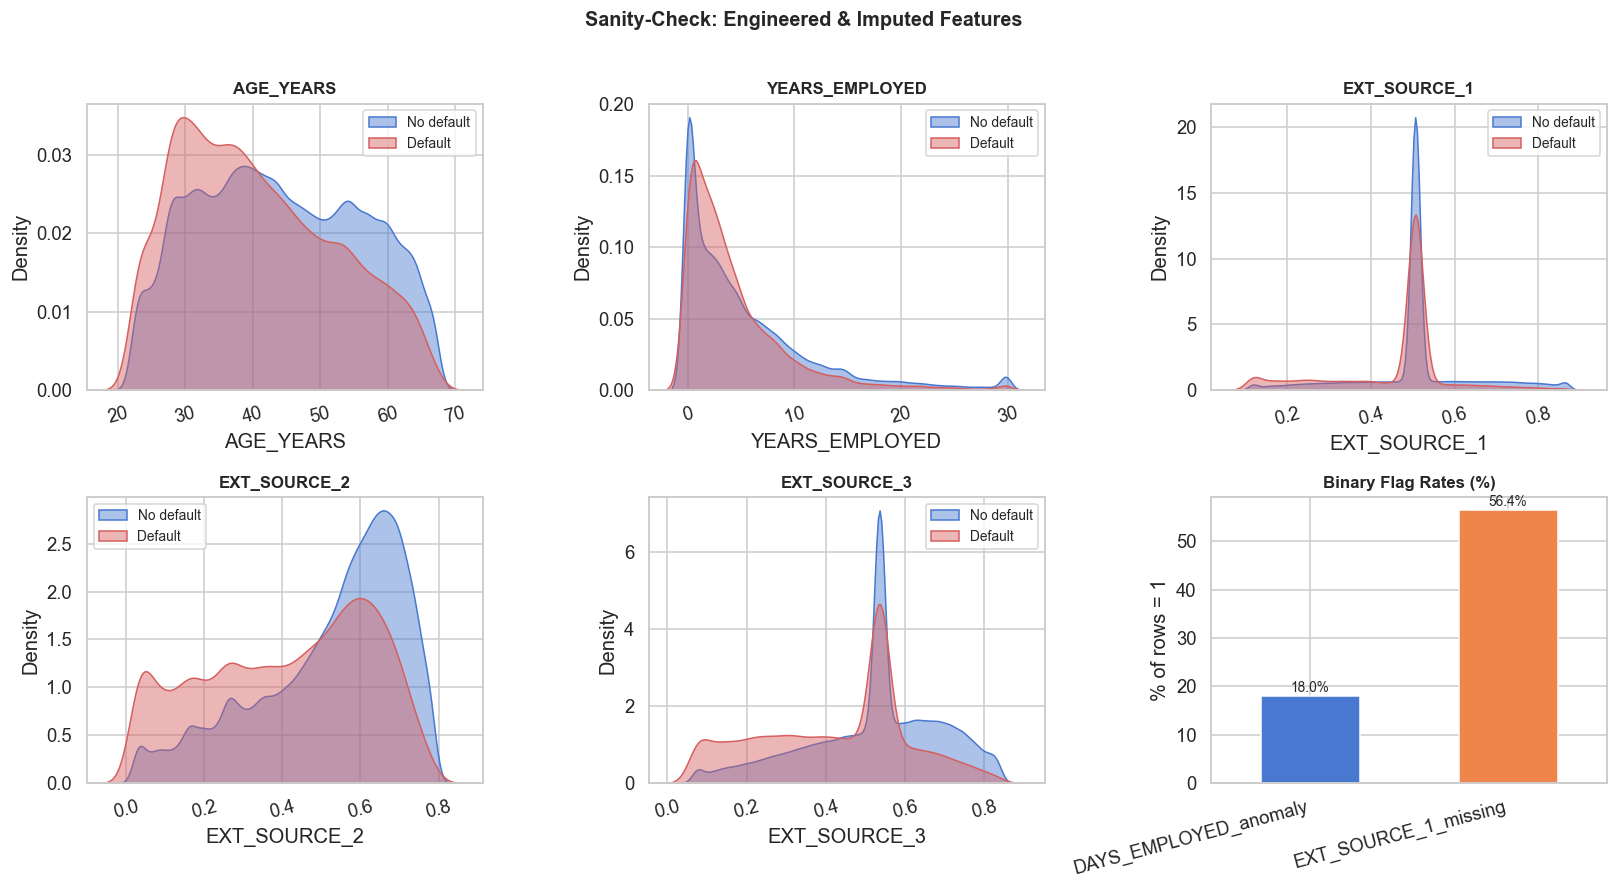

In [28]:
CHECK_COLS = ['AGE_YEARS', 'YEARS_EMPLOYED', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
palette = {0: sns.color_palette('muted')[0], 1: sns.color_palette('muted')[3]}

for i, col in enumerate(CHECK_COLS):
    ax = axes[i]
    lo = df[col].quantile(0.01)
    hi = df[col].quantile(0.99)
    clipped = df[col].clip(lo, hi)
    for tv, lbl in [(0, 'No default'), (1, 'Default')]:
        sns.kdeplot(
            clipped[df['TARGET'] == tv],
            ax=ax, fill=True, alpha=0.45,
            color=palette[tv], label=lbl
        )
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', labelrotation=15)

# Flag column distributions (bar chart)
ax = axes[5]
flag_summary = (
    df[['DAYS_EMPLOYED_anomaly', 'EXT_SOURCE_1_missing']]
    .mean() * 100
)
flag_summary.plot.bar(ax=ax, color=sns.color_palette('muted', 2), edgecolor='white')
ax.set_title('Binary Flag Rates (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('% of rows = 1')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=9
    )

fig.suptitle('Sanity-Check: Engineered & Imputed Features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## 4. Feature Type Separation

We split the columns into **numerical** and **categorical** groups based on dtype.  
We also exclude `SK_ID_CURR` (an ID with no predictive value) and `TARGET` from feature analysis.

In [29]:
EXCLUDE = ['SK_ID_CURR', 'TARGET']
features = [c for c in df.columns if c not in EXCLUDE]

numerical_cols   = df[features].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df[features].select_dtypes(include=['object']).columns.tolist()

print(f'Numerical features  : {len(numerical_cols)}')
print(f'Categorical features: {len(categorical_cols)}')
print(f'\nCategorical columns : {categorical_cols}')

Numerical features  : 78
Categorical features: 13

Categorical columns : ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'EMERGENCYSTATE_MODE']


---
## 5. Numerical Feature Distributions

We focus on a handful of **financially meaningful** numerical features rather than plotting all 100+.  
For each we show distributions split by target class (defaulted vs. not) — this immediately surfaces which features are discriminative.

The selected features cover income, credit amounts, age, employment, and external credit bureau scores — all well-known risk drivers.

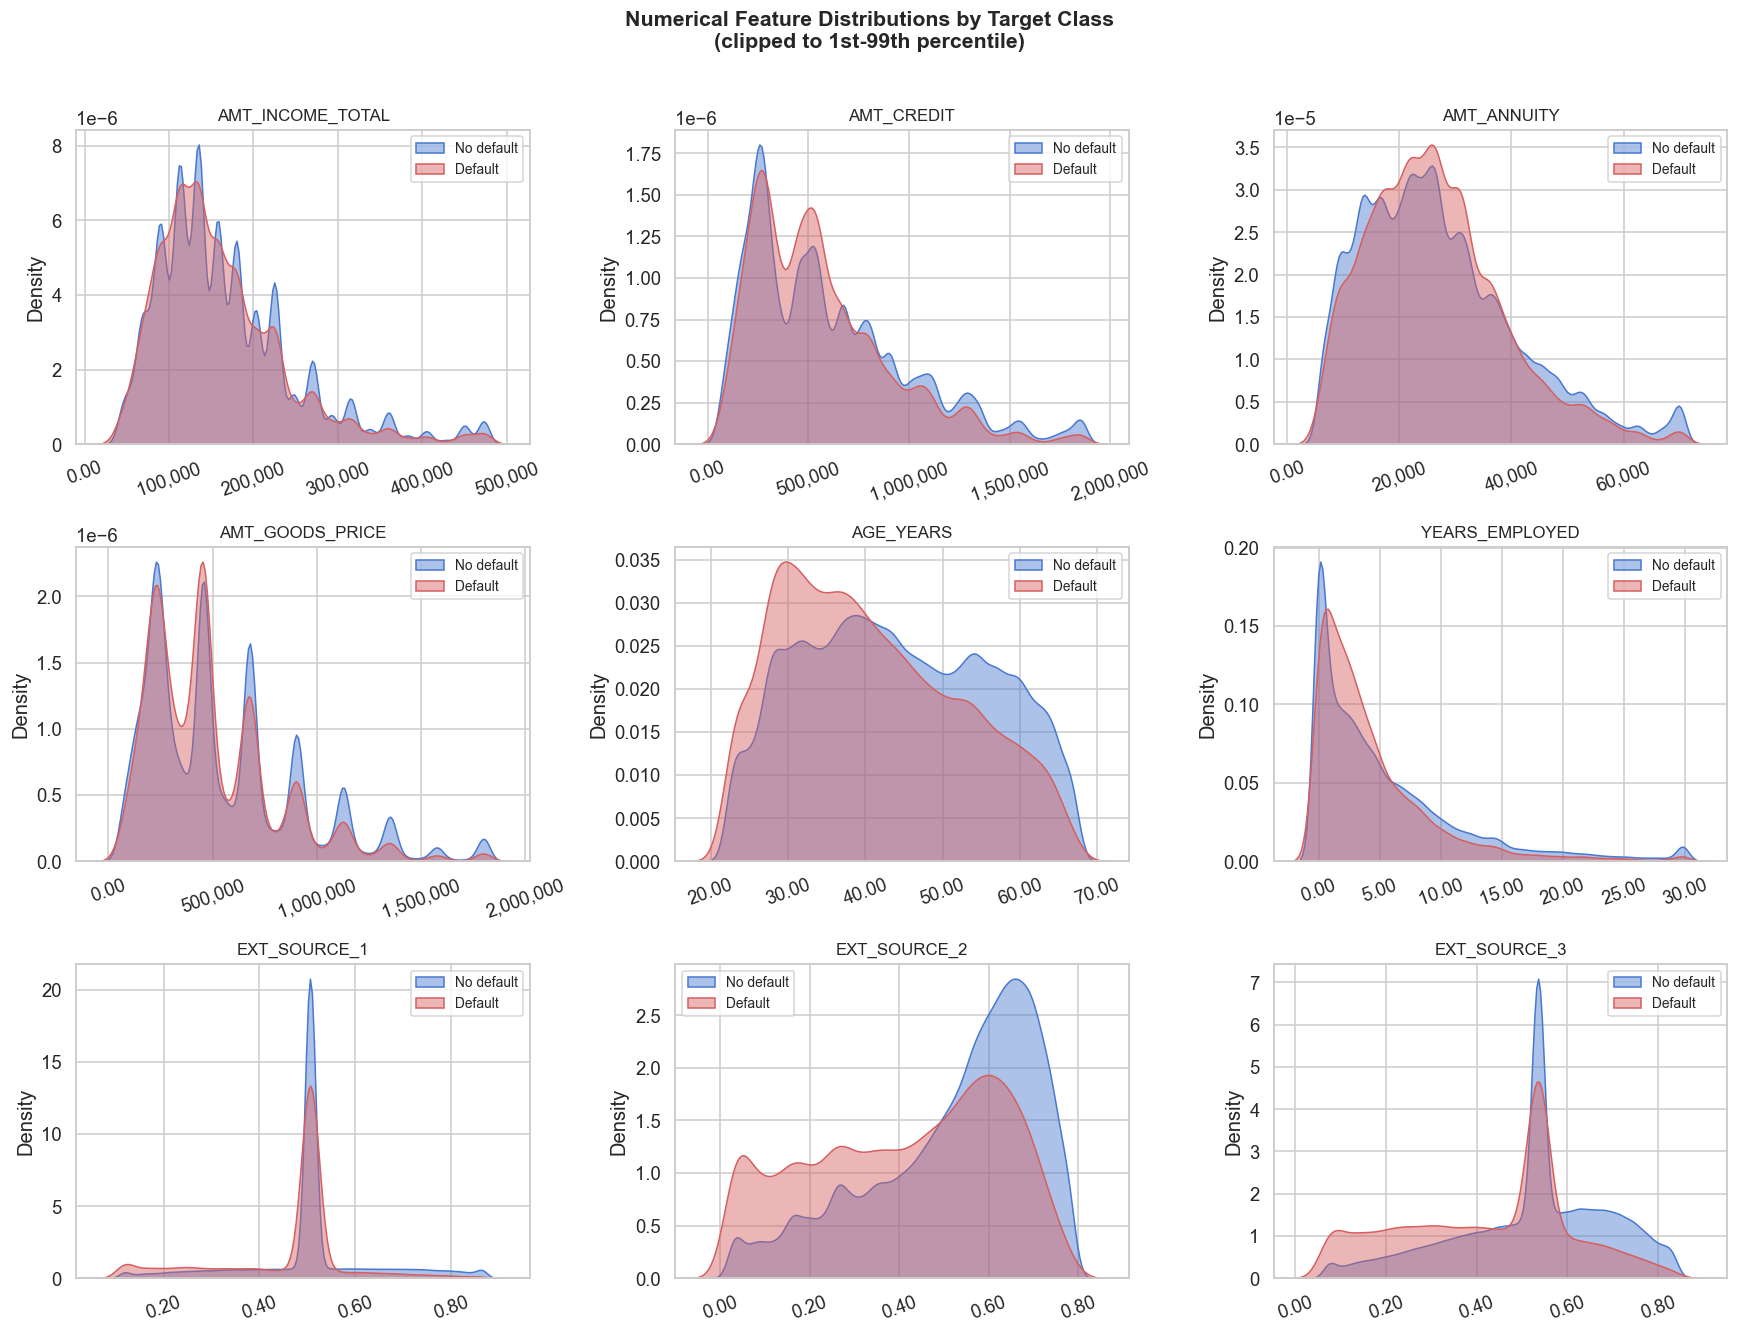

In [30]:
TOP_NUM_FEATURES = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'AGE_YEARS',
    'YEARS_EMPLOYED',
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3',
]

n_cols = 3
n_rows = int(np.ceil(len(TOP_NUM_FEATURES) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

palette = {0: sns.color_palette('muted')[0], 1: sns.color_palette('muted')[3]}

for i, col in enumerate(TOP_NUM_FEATURES):
    ax = axes[i]
    lo, hi = df[col].quantile(0.01), df[col].quantile(0.99)
    plot_data = df[[col, 'TARGET']].copy()
    plot_data[col] = plot_data[col].clip(lo, hi)

    for target_val, label in [(0, 'No default'), (1, 'Default')]:
        subset = plot_data.loc[plot_data['TARGET'] == target_val, col].dropna()
        sns.kdeplot(subset, ax=ax, fill=True, alpha=0.45,
                    color=palette[target_val], label=label)

    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x:,.0f}' if abs(x) >= 1000 else f'{x:.2f}'
    ))
    ax.tick_params(axis='x', labelrotation=20)

for j in range(len(TOP_NUM_FEATURES), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Numerical Feature Distributions by Target Class\n(clipped to 1st-99th percentile)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [31]:
df[TOP_NUM_FEATURES].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.92,237123.15,25650.00,112500.00,147150.00,202500.00,1.170000e+08
AMT_CREDIT,307511.0,599026.00,402490.78,45000.00,270000.00,513531.00,808650.00,4.050000e+06
AMT_ANNUITY,307511.0,27108.49,14493.46,1615.50,16524.00,24903.00,34596.00,2.580255e+05
AMT_GOODS_PRICE,307511.0,538316.29,369288.98,40500.00,238500.00,450000.00,679500.00,4.050000e+06
AGE_YEARS,307511.0,43.91,11.95,20.50,33.98,43.12,53.89,6.907000e+01
YEARS_EMPLOYED,307511.0,5.35,6.32,0.00,0.79,3.32,7.56,4.904000e+01
EXT_SOURCE_1,307511.0,0.50,0.14,0.01,0.51,0.51,0.51,9.600000e-01
EXT_SOURCE_2,307511.0,0.51,0.19,0.00,0.39,0.57,0.66,8.500000e-01
EXT_SOURCE_3,307511.0,0.52,0.17,0.00,0.42,0.54,0.64,9.000000e-01


**Observations:**
- `DAYS_BIRTH` distributions are shifted — older applicants tend to have lower default rates (negative values represent days before the application date, i.e. age in days)
- `EXT_SOURCE_1/2/3` are external credit bureau scores; defaulters cluster at lower values, making these strong predictors
- `DAYS_EMPLOYED` has anomalous large positive values (~365243) representing unemployed/self-employed applicants — encode as a binary flag before using as continuous
- `AMT_INCOME_TOTAL` and `AMT_CREDIT` are right-skewed; log-transforms will help linear models

---
## 6. Categorical Feature Value Counts

For categorical columns we plot the **default rate per category** rather than raw counts, so we can see which category levels are genuinely riskier (not just more common in the data).

The bars are sorted by default rate and annotated with the sample size `n` per category.

In [32]:
print('Categorical columns and their cardinality:')
card = df[categorical_cols].nunique().sort_values()
print(card.to_string())

Categorical columns and their cardinality:
NAME_CONTRACT_TYPE             2
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
EMERGENCYSTATE_MODE            2
CODE_GENDER                    3
NAME_EDUCATION_TYPE            5
NAME_HOUSING_TYPE              6
NAME_FAMILY_STATUS             6
WEEKDAY_APPR_PROCESS_START     7
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               8
OCCUPATION_TYPE               18
ORGANIZATION_TYPE             58


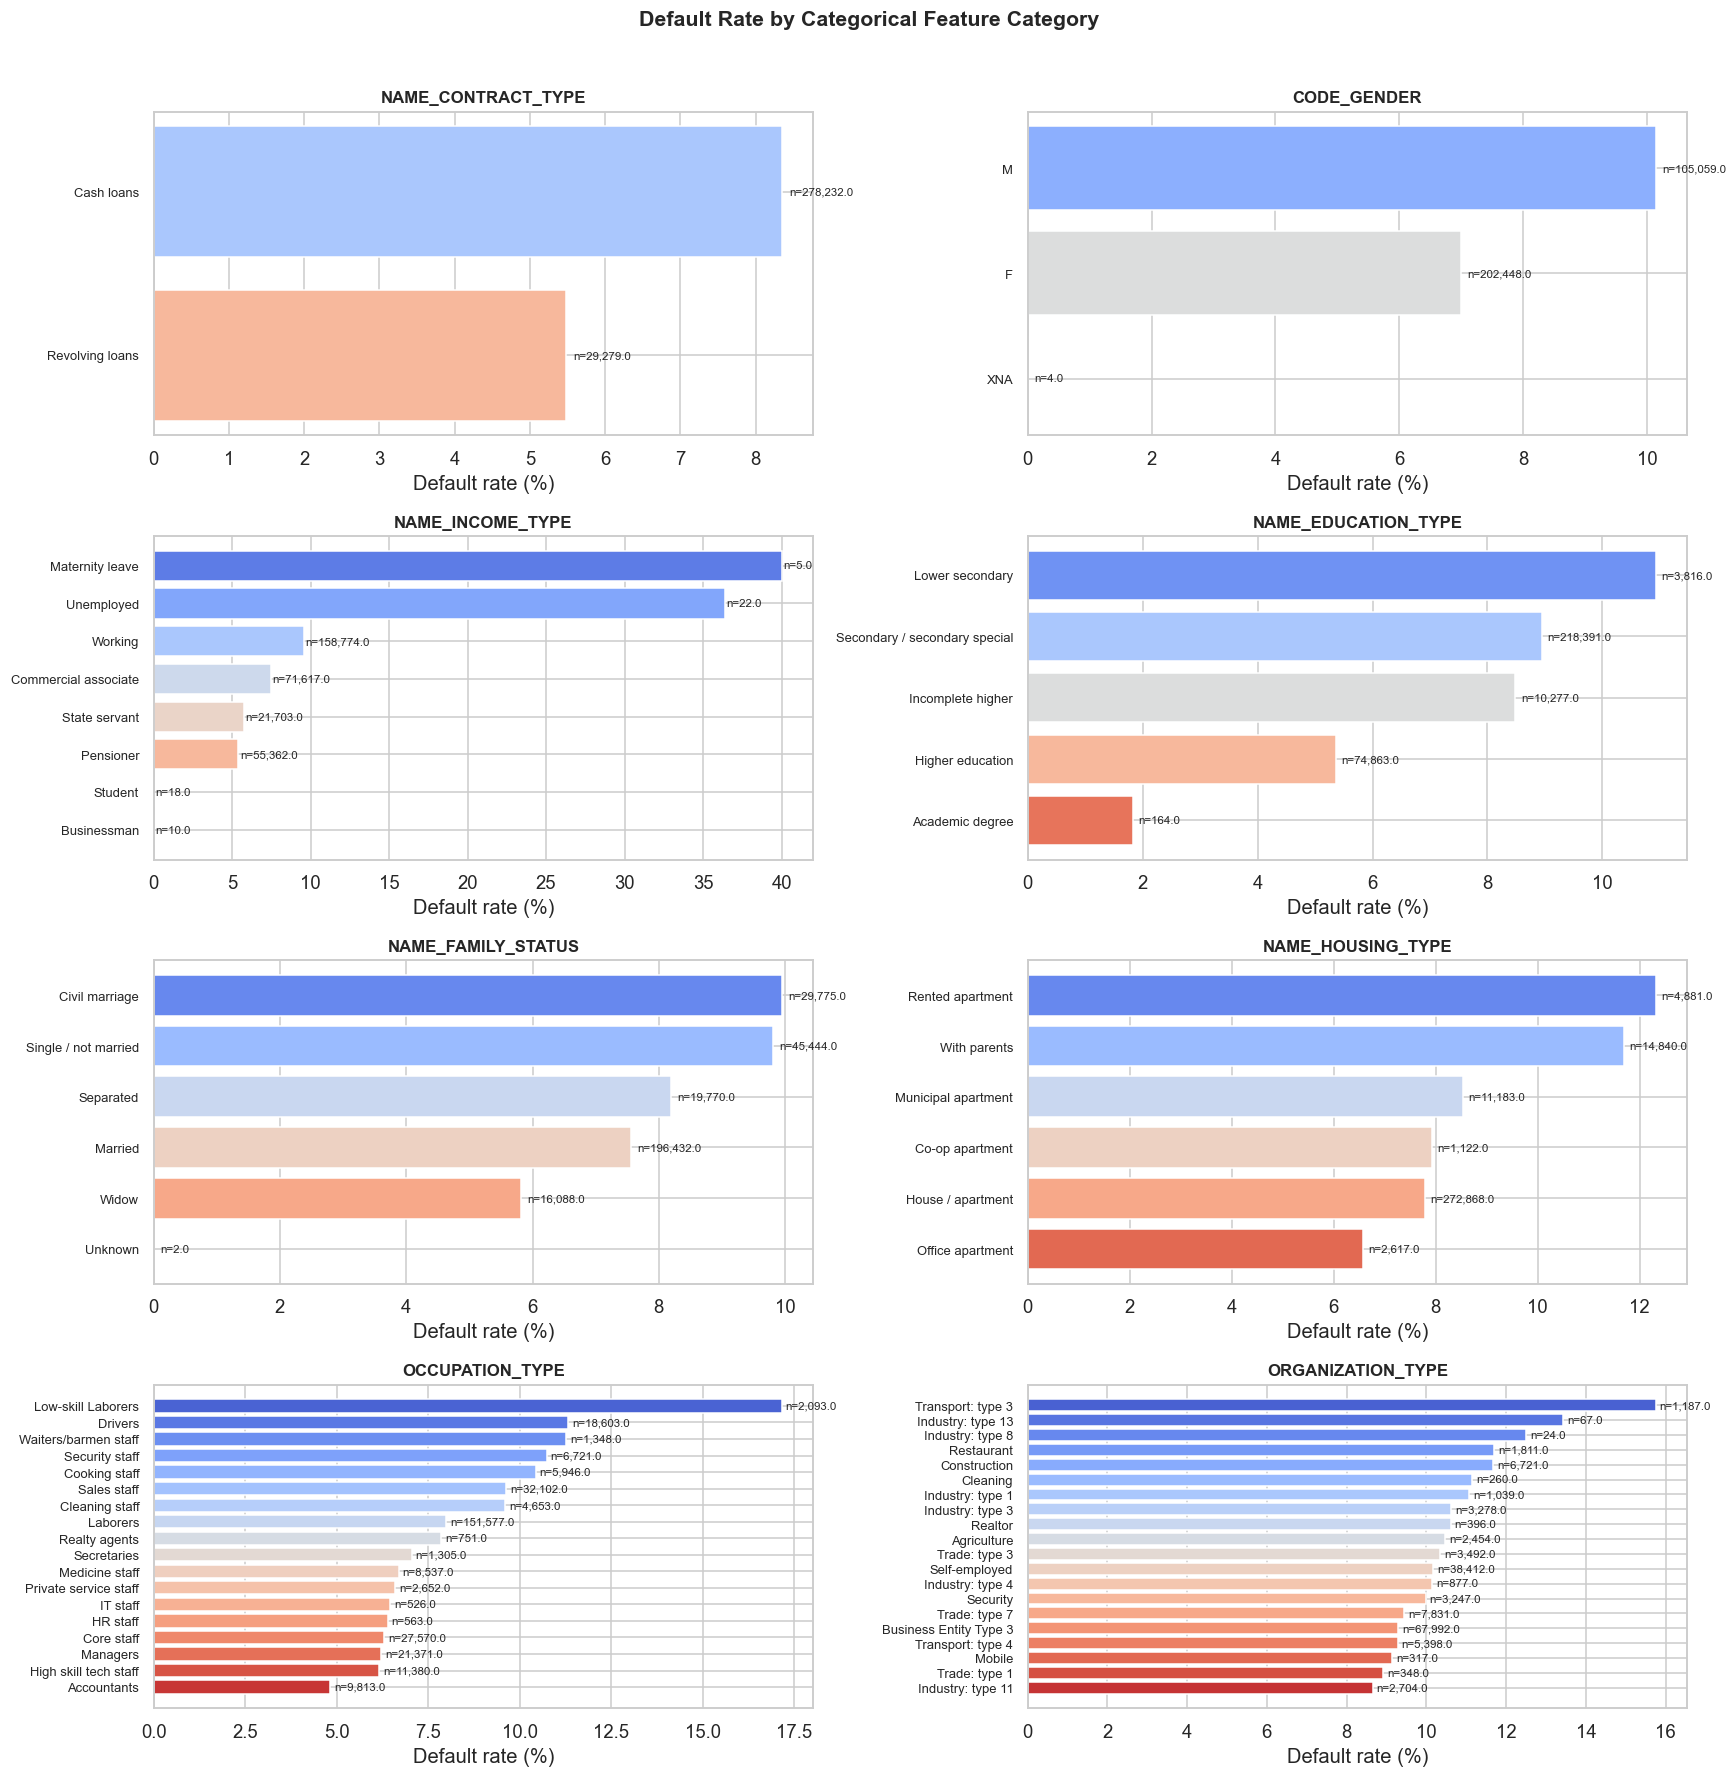

In [33]:
TOP_CAT_FEATURES = [
    'NAME_CONTRACT_TYPE',
    'CODE_GENDER',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE',
    'ORGANIZATION_TYPE',
]

n_cols = 2
n_rows = int(np.ceil(len(TOP_CAT_FEATURES) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(TOP_CAT_FEATURES):
    ax = axes[i]

    stats = (
        df.groupby(col)['TARGET']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'default_rate', 'count': 'n'})
        .sort_values('default_rate', ascending=True)
    )
    if len(stats) > 20:
        stats = stats.tail(20)

    colors_bar = sns.color_palette('coolwarm_r', len(stats))
    bars = ax.barh(stats.index, stats['default_rate'] * 100,
                   color=colors_bar, edgecolor='white')

    for bar, (_, row) in zip(bars, stats.iterrows()):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                f'n={row["n"]:,}', va='center', fontsize=7.5)

    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Default rate (%)')
    ax.tick_params(axis='y', labelsize=8.5)

for j in range(len(TOP_CAT_FEATURES), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Default Rate by Categorical Feature Category',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Observations:**
- `CODE_GENDER`: males default at a noticeably higher rate than females; the `XNA` category (small group) should be examined separately
- `NAME_EDUCATION_TYPE`: lower education levels correlate with higher default rates
- `NAME_INCOME_TYPE`: working-class applicants show elevated risk; pensioners are safer
- `ORGANIZATION_TYPE` and `OCCUPATION_TYPE` have high cardinality — some sectors (e.g. Transport) carry meaningfully more risk than others
- `NAME_CONTRACT_TYPE`: revolving loans default more often than cash loans

---
## 7. Correlation Heatmap

A correlation matrix on a selected subset of numerical features highlights multicollinearity — pairs of features that carry redundant information.  
High correlation (|r| > 0.8) between predictors can destabilise logistic regression coefficients and is worth noting before feature selection.

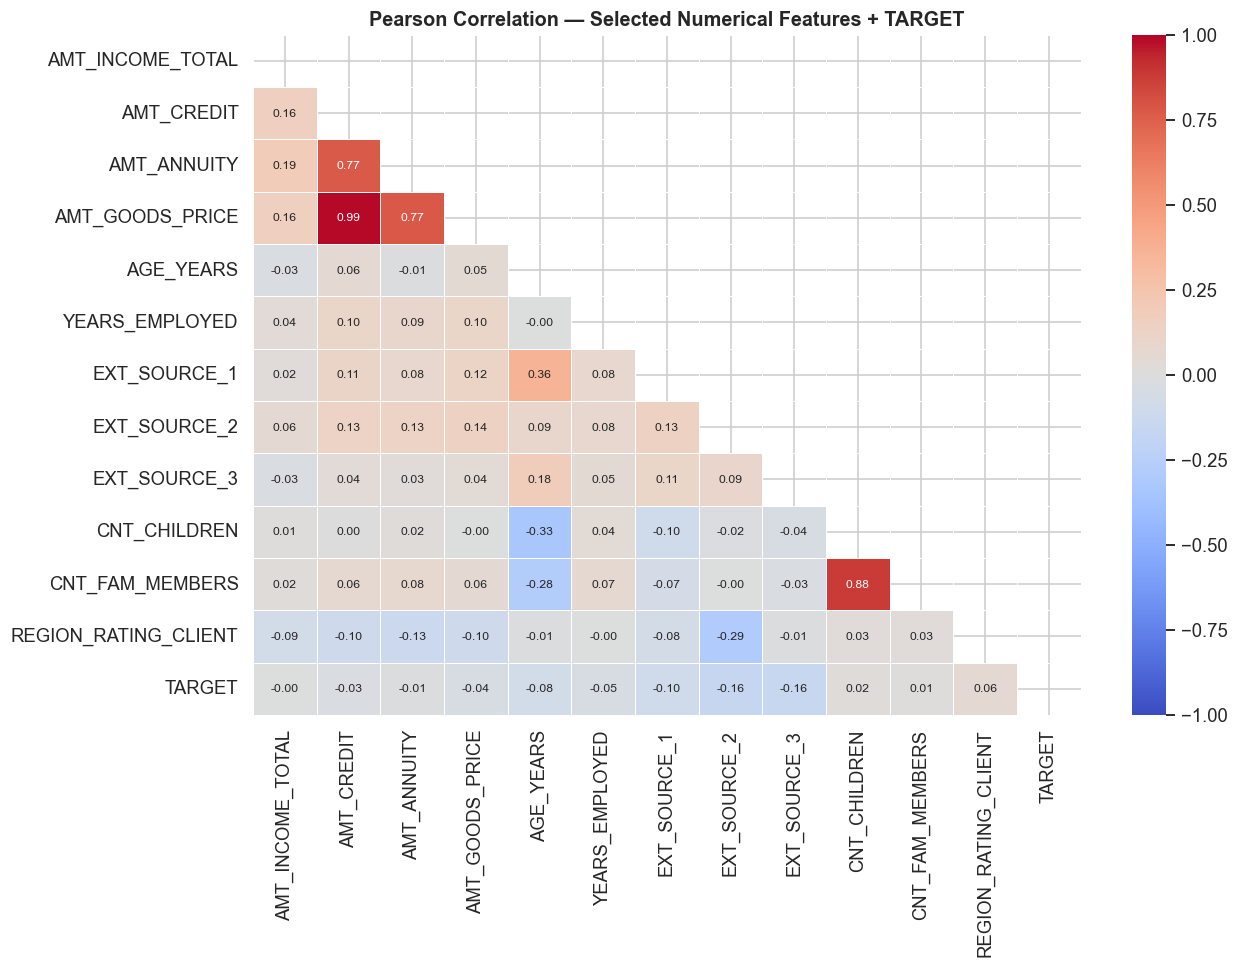

In [34]:
CORR_FEATURES = TOP_NUM_FEATURES + ['CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT']
corr = df[CORR_FEATURES + ['TARGET']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax,
    annot_kws={'size': 8}, vmin=-1, vmax=1
)
ax.set_title('Pearson Correlation — Selected Numerical Features + TARGET', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary

| Finding | Implication for modelling |
|---|---|
| **~8% default rate** | Use AUC-ROC / average-precision; consider class weights or SMOTE |
| **~67 columns have missing values** | Need imputation strategy; missingness indicators may add signal |
| **EXT_SOURCE 1/2/3 are strong predictors** | Top-priority features; missing values warrant careful imputation |
| **DAYS_EMPLOYED anomaly (365,243)** | Encode as a separate binary flag before using as continuous feature |
| **AMT_* features are right-skewed** | Log-transform for linear models; tree-based models handle natively |
| **High-cardinality categoricals** | Target-encode or group rare levels to avoid sparse one-hot representations |

**Next steps:** feature engineering notebook (`02_feature_engineering.ipynb`) — derive age, employment tenure, credit-to-income ratio, anomaly flags, and interaction terms.